In [1]:
from jax import config
config.update("jax_enable_x64", True)
import jax
jax.devices()

[CudaDevice(id=0)]

In [2]:
import sys
sys.path.append('/mnt/home/igaron/gplvm')

import jax.numpy as jnp
from tqdm import tqdm 

import matplotlib.pyplot as plt
from core import GPLVM, DynamicGPLVM, Layer, Proposal
from mc_samplers import Roberts
import mappings
import noise_models as noise_models
import jaxopt
from jax.nn import softplus
%load_ext autoreload
%autoreload 2

Construct

In [74]:
num_neurons = 30
num_dims = 1
basis_params = {
                "max_freq": 30, 
                "num_dims": num_dims, 
                "out_scale":20., 
                "len_scale":.8,
                "bias_mean": 0,
                "bias_std": 0,
                "num_neurons":num_neurons,
                "tol":1e-4,
                "nonlinearity":lambda x: softplus(x),
                }

'''model = GPLVM(num_dims = num_dims, 
    observation=Layer(
        mapping=mappings.WeightedFourierBasisMapping(basis_params),
        noise=noise_models.IsotropicGaussian(.005),
    ),
    latent_prior=Layer(
        mapping=mappings.identity,
        noise=noise_models.UniformSobol(0, .8)
    ), mc_scale = 0.8)'''

model = GPLVM(num_dims = num_dims, 
    observation=Layer(
        mapping=[mappings.WeightedFourierBasisMapping(basis_params),
                                        mappings.IdentityMapping()],# ['Y', 'S']),
        noise=[noise_models.IsotropicGaussian(.005),noise_models.Beta(.0001, .8)], #['Y', 'S'], 'EIV')
    ),
    latent_prior=Layer(
        mapping=mappings.identity,
        noise=noise_models.UniformSobol(0, .8)
    ), mc_scale = 0.8)

[<mappings.WeightedFourierBasisMapping object at 0x154324feecd0>, <mappings.IdentityMapping object at 0x154324e7c390>]
[<noise_models.IsotropicGaussian object at 0x154326d89990>, <noise_models.Beta object at 0x154324d87410>]


Simulate

[[-1.18428442 -0.11617041  0.17269028  0.95730718 -0.83295415  0.69080517
   0.07545021 -0.7645271  -0.05064539 -1.35247421 -0.98591734 -1.11984789
   0.47528387  0.59333693  1.28129042 -0.64617864  0.74963106 -0.48255832
   1.36086336  0.16367777 -1.25591128 -1.48948272  1.09440841  0.4482111
   2.29283663 -0.76433874  1.35090434 -0.34514531  0.36712543  0.10898   ]
 [ 0.0352765   0.79059617  0.54657786 -2.10464558  2.85227983  1.06448585
  -0.31624672 -0.78112209  0.1500697   2.5803732  -0.58560534 -1.63873373
  -0.55103643  1.21322369 -0.01739902  0.19089498  2.33814035 -0.37978906
   0.12998895 -0.54136531 -1.831593    1.1877065  -0.01573457 -1.46887993
  -0.00695409  1.28560239  0.51534167 -0.60537592  0.6083738   0.21711398]
 [-0.874855    1.78641326 -1.11872731  0.64962664  0.06701765 -0.26136837
  -0.58371352 -0.63309837  0.63120292  0.3249686  -0.32873663 -1.91330256
  -1.83263458  1.62605555  0.55867976 -0.48126949 -0.45309617 -0.1295505
   0.01632832  0.44215978 -1.14090403 

Text(0.5, 0, 'Stimulus')

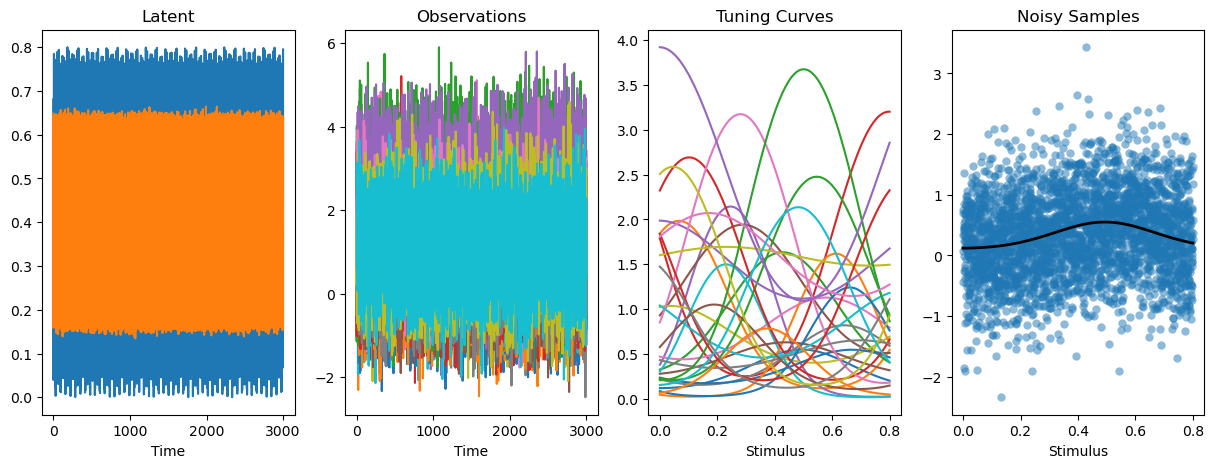

In [92]:
num_steps = 3000

# Sample true parameters of model
true_weights = jax.random.normal(
                        jax.random.PRNGKey(1), 
                        shape=(model.observation.mapping.mappings[0].params_per_neuron, num_neurons)
                    )

xs_true, ys = model.simulate(
    key=jax.random.PRNGKey(0),
    params=[true_weights, None],
    num_observations=jnp.ones((num_steps, num_dims))
    # TODO - I don't like this
)
fig, axes = plt.subplots(1, 4, figsize=(15,5))

axes[0].set_title("Latent")
axes[0].plot(xs_true)
axes[0].plot(ys[1])
axes[0].set_xlabel("Time")

axes[1].set_title("Observations")
axes[1].plot(ys[0])
axes[1].set_xlabel("Time")

x_grid = jnp.linspace(0, .8, 100)[:, None]
true_tunings = model.observation.mapping([true_weights, None], x_grid)[0]

axes[2].set_title("Tuning Curves")
axes[2].plot(x_grid, true_tunings)
axes[2].set_xlabel("Stimulus")

axes[3].set_title("Noisy Samples")
axes[3].scatter(xs_true, ys[0][:,0], lw=0, alpha=.5)
axes[3].plot(x_grid, true_tunings[:,0], "k", lw=2)
axes[3].set_xlabel("Stimulus")


Optimize

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:05<00:00, 38.63it/s]


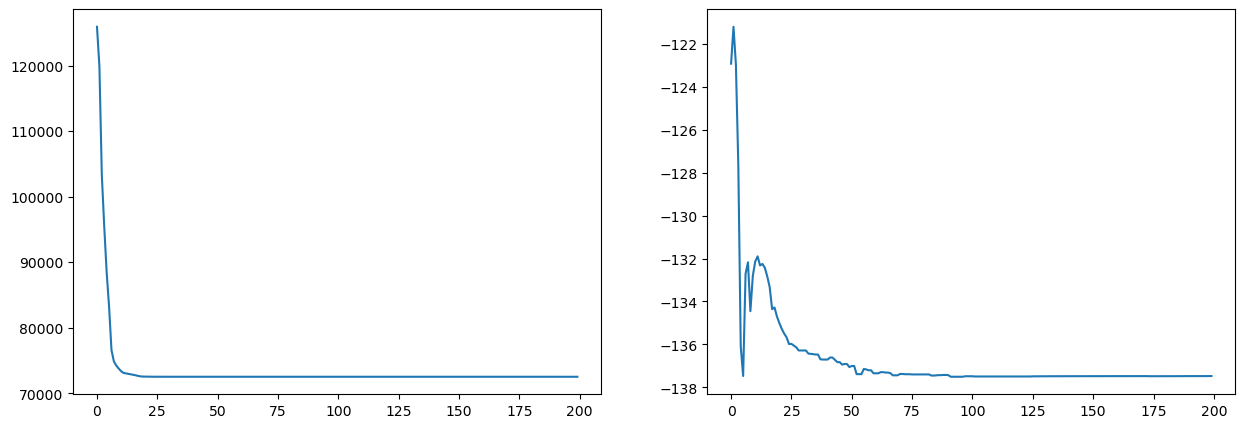

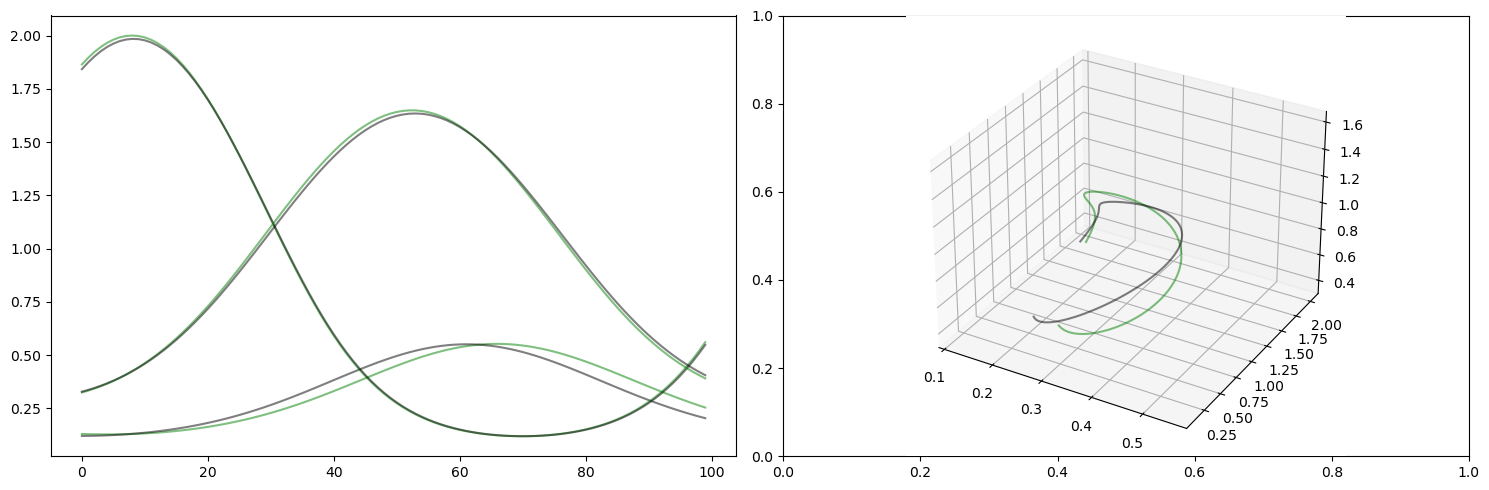

In [98]:
est_params = [jax.random.normal(
                        jax.random.PRNGKey(17), 
                        shape=(model.observation.mapping.mappings[0].params_per_neuron, num_neurons)
                    ), None]

opt_params = {
    "init_params":est_params,
    "save_prior":True,
    "opt_key":jax.random.PRNGKey(123),
    "init_key":jax.random.PRNGKey(2),
    "n_iters":  200
}

model.fit(ys, "lbfgs", opt_params)
    
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].plot(model.objhist_)
axes[1].plot(model.priorhist_)

true_tunings = model.observation.mapping([true_weights, None], x_grid)[0]
est_tunings = model.observation.mapping(model.params_, x_grid)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5), subplot_kw={'projection': None})

for i in range(3):       
    ax1.plot(est_tunings[:,i], c='green', alpha=.5)
    ax1.plot(true_tunings[:,i], c='k', alpha=.5)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.5)
ax2.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.5)
plt.tight_layout()
plt.show()

In [102]:

est_params =  [jax.random.normal(
                        jax.random.PRNGKey(17), 
                        shape=(model.observation.mapping.mappings[0].params_per_neuron, num_neurons)
                    ), None]
opt_params = {
    "init_params":False,
    "opt_key":jax.random.PRNGKey(123),
    "init_key":jax.random.PRNGKey(2),
    "n_iters": 10000,
    "n_chains": 12,
    "friction":0.1,
    "min_lr": 1e-6,
    "max_lr": 1e-5,
    "noise_multiplier":1.,
    "burn_in":5000,
    "save_every":500,
    "params_per_neuron":est_params[0].shape[0],
    "num_neurons":num_neurons
}

model.fit(ys, "ula", opt_params)
    
plt.figure()
model.objhist_ = jnp.array(model.objhist_)
plt.plot(model.objhist_)
plt.axhline(model.log_posterior_params(true_weights, ys, jax.random.PRNGKey(0)), dashes=[2, 2], color='k')
plt.ylim(jnp.max(model.objhist_) + jnp.max(model.objhist_)/10, jnp.max(model.objhist_)+1000)

fig = plt.figure()
fig, ax2 = plt.subplots(1, 1, sharex=True, sharey=True)
fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')

true_tunings = model.observation.mapping(true_weights, x_grid)
ax1.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.5)
ax2.plot(true_tunings[:,:3], c='k', alpha=.5)

chain_ind=5
for i in range(10):
    for j in range(3):
        curr_param = model.saved_params_[i][chain_ind,:,:]
        est_tunings = model.observation.mapping(curr_param, x_grid)
        print(est_tunings.shape)
        ax1.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.5)
        ax2.plot(est_tunings[:,:3], c='green', alpha=.5)


  0%|                                                                                                                      | 0/10000 [00:00<?, ?it/s]

Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>


TypeError: unsupported operand type(s) for *: 'DynamicJaxprTracer' and 'list'

(100, 30)
(100, 30)
(100, 30)
(100, 30)
(100, 30)
(100, 30)
(100, 30)
(100, 30)
(100, 30)


IndexError: list index out of range

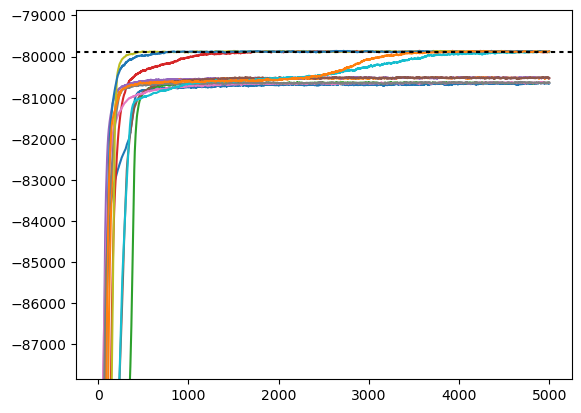

<Figure size 640x480 with 0 Axes>

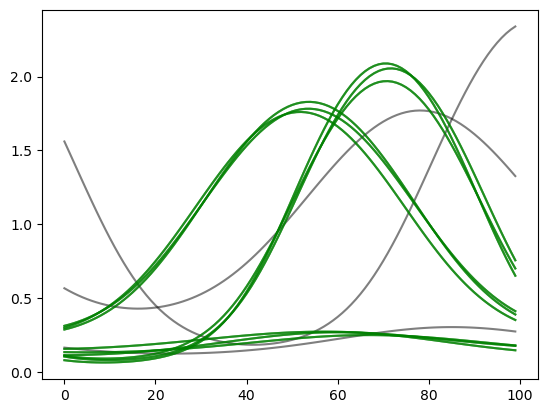

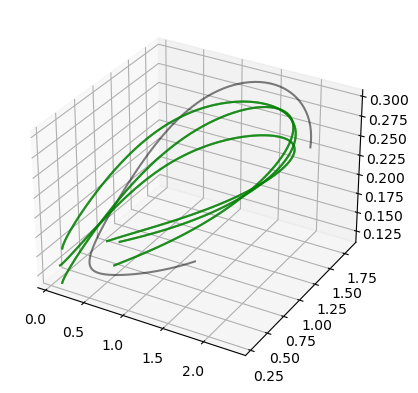

In [73]:
plt.figure()
model.objhist_ = jnp.array(model.objhist_)
plt.plot(model.objhist_)
plt.axhline(model.log_posterior_params(true_weights, ys, jax.random.PRNGKey(0)), dashes=[2, 2], color='k')
plt.ylim(jnp.max(model.objhist_) + jnp.max(model.objhist_)/10, jnp.max(model.objhist_)+1000)
#(-59895.041942465905, -79860.05592328787)


fig = plt.figure()
fig, ax2 = plt.subplots(1, 1, sharex=True, sharey=True)
fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')

true_tunings = model.observation.mapping(true_weights, x_grid)
ax1.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.5)
ax2.plot(true_tunings[:,:3], c='k', alpha=.5)

chain_ind=5
for i in range(10):
    for j in range(3):
        curr_param = model.saved_params_[i][chain_ind,:,:]
        est_tunings = model.observation.mapping(curr_param, x_grid)
        print(est_tunings.shape)
        ax1.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.5)
        ax2.plot(est_tunings[:,:3], c='green', alpha=.5)


Traced<ShapedArray(float64[1024,1])>with<DynamicJaxprTrace>


100%|███████████████████████████| 100/100 [00:04<00:00, 24.82it/s]


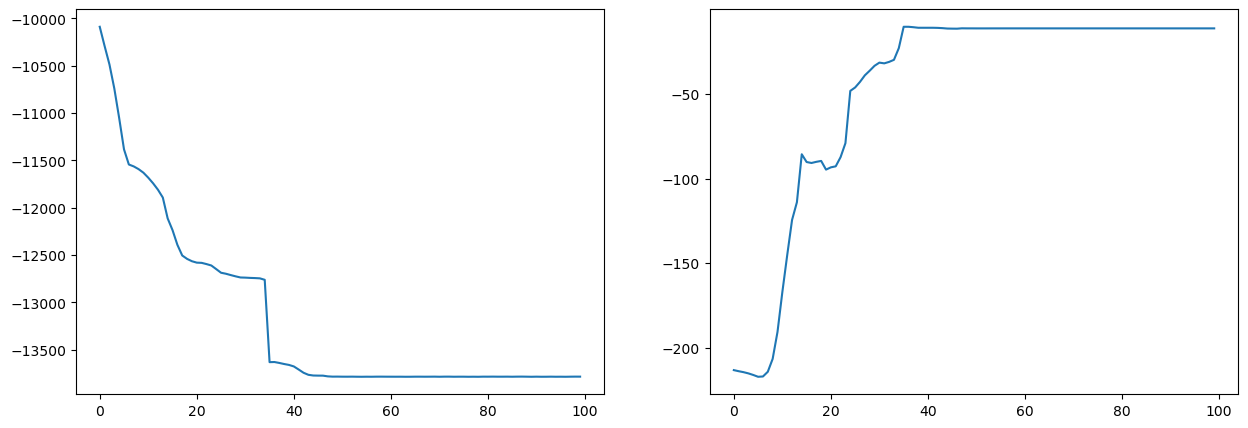

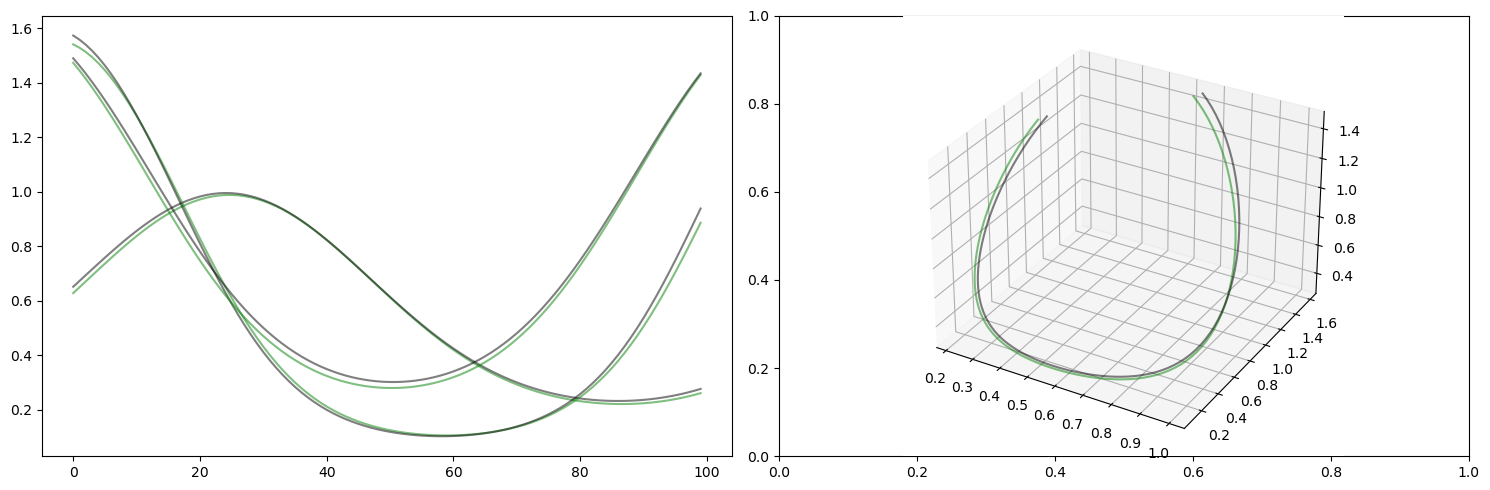

[Array([[-0.43541434, -0.43271764,  0.150508  ],
       [ 0.90986074, -0.26564589, -0.71062273],
       [ 0.30166492,  1.73243365,  1.06251549]], dtype=float64), None]


In [ ]:

est_params =  model.observation.mapping.sample(jax.random.PRNGKey(3), 
                                            ["FIX THIS", None])

def objective(*args):
    return -1 * model.log_posterior_params(*args)

# Initialize optimization method
solver = jaxopt.LBFGS(fun=objective)
key = jax.random.PRNGKey(123)

state = solver.init_state(
    est_params, ys, key
)
######### NEXT TO DO _ separaete trees
objhist = []
priorhist = []
eivhist = []

for key in tqdm(jax.random.split(jax.random.PRNGKey(0), 100)):
    
    est_params, state = solver.update(
        est_params, state, ys, key
    )
    priorhist.append(model.observation.mapping.log_density(est_params))
    objhist.append(state.value)
    
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].plot(objhist)
axes[1].plot(priorhist)

true_tunings = model.observation.mapping(true_weights, x_grid)[0]
est_tunings = model.observation.mapping(est_params, x_grid)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5), subplot_kw={'projection': None})

for i in range(3):       
    ax1.plot(est_tunings[:,i], c='green', alpha=.5)
    ax1.plot(true_tunings[:,i], c='k', alpha=.5)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.5)
ax2.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.5)
plt.tight_layout()
plt.show()
print(est_params)

In [ ]:
num_neurons = 3
basis_params = {
                "max_freq": 30, 
                "num_dims": 1, 
                "out_scale": 5, 
                "len_scale": .9,
                "bias_mean": 0,
                "bias_std": 0,
                "num_neurons":3,
                "tol":1e-4,
                "nonlinearity":lambda x: softplus(x)
                }

proposal = Proposal(
    layer=Layer(
        mapping=mappings.identity,
        noise=noise_models.ProjectedNormal(0.5)
    ),
    params= Params(None, jnp.array(0.5)),
    init_params=Params(None, jnp.array(0.5)),
    init_loc = jnp.zeros(num_dims)                   
)

# TODO fix the 1
model = DynamicGPLVM(1, 
    transition=Layer(
        mapping=mappings.identity,
        noise=noise_models.ProjectedNormal(5.)
    ),
    observation= Layer(
        mapping=[mappings.WeightedFourierBasisMapping(basis_params),
                                        mappings.IdentityMapping()],
        noise=[noise_models.Poisson(),noise_models.ProjectedNormal(5.)]
    ),num_samples = 50,
    proposal = proposal, 
)

true_weights = model.observation.mapping.sample(jax.random.PRNGKey(5), 
                                            ["FIX THIS", None])


xs_true, ys = model.simulate(
    key=jax.random.PRNGKey(0),
    params=true_weights,
    x_init=jnp.zeros(num_dims), 
    num_timesteps=100 # for static, this is an array of values
)
fig, axes = plt.subplots(1, 4, figsize=(15,5))

axes[0].set_title("Latent")
axes[0].plot(xs_true[:100])
axes[0].plot(ys[1][:100])
axes[0].set_xlabel("Time")

axes[1].set_title("Observations")
axes[1].plot(ys[0][:, :2])
axes[1].set_xlabel("Time")

x_grid = jnp.linspace(0,1, 100)[:, None]
true_tunings = model.observation.mapping(true_weights, x_grid)[0]
axes[2].set_title("Tuning Curves")
axes[2].plot(x_grid, true_tunings)
axes[2].set_xlabel("Stimulus")

axes[3].set_title("Noisy Samples")
axes[3].scatter(xs_true, ys[0][:, 0], lw=0, alpha=.5)
axes[3].plot(x_grid, true_tunings, "k", lw=2)
axes[3].set_xlabel("Stimulus")

NameError: name 'Params' is not defined

In [ ]:
import time
import jax
import jax.numpy as jnp
import smc
from collections import namedtuple

Params = namedtuple('Params', ['weights', 'whatever'])
temp_par = Params(init_weights, None)
# Measure compilation time
start_time = time.time()
smc.log_marginal_likelihood(temp_par, ys, key, model.proposal.initialize,  
                    model.proposal.sample, model.log_transition_prob,
                    model.logp_y_given_x, model.num_samples,
            ).block_until_ready() # Forces computation
print("First call (compilation + execution):", time.time() - start_time)

# Measure execution time (no compilation)
start_time = time.time()
smc.log_marginal_likelihood(temp_par, ys, key, model.proposal.initialize,  
                    model.proposal.sample, model.log_transition_prob,
                    model.logp_y_given_x, model.num_samples,
            ).block_until_ready()
print("Subsequent calls (execution only):", time.time() - start_time)

jax.make_jaxpr(smc.log_marginal_likelihood)(temp_par, ys, key, jnp.array(0.),  
                    model.proposal.sample, model.log_transition_prob,
                    model.logp_y_given_x, model.num_samples,
            )

NameError: name 'init_weights' is not defined

In [ ]:
start_time = time.time()
for elem in proposal.sample(key, jnp.array(100)):
    elem.block_until_ready()
print("First call (compilation + execution):", time.time() - start_time)

# Measure execution time (no compilation)
start_time = time.time()
for elem in proposal.sample(key, 100):
    elem.block_until_ready()
print("Subsequent calls (execution only):", time.time() - start_time)

jax.make_jaxpr(smc.log_marginal_likelihood)(temp_par, ys, key, jnp.array(0.),  
                    model.proposal.sample, model.log_transition_prob,
                    model.logp_y_given_x, model.num_samples,
            )

NameError: name 'proposal' is not defined

In [ ]:

est_params =  model.observation.mapping.sample(jax.random.PRNGKey(5), 
                                            ["FIX THIS", None])


def objective(*args):
    return -1 * model.log_posterior_params(*args)

# Initialize optimization method
solver = jaxopt.LBFGS(fun=objective)
key = jax.random.PRNGKey(123)


state = solver.init_state(
    est_params, ys, key
)

objhist = []
priorhist = []
eivhist = []
for key in tqdm(jax.random.split(jax.random.PRNGKey(0), 300)):
    
    est_params, state = solver.update(
        est_params, state, ys, key
    )
    priorhist.append(model.observation.mapping.log_density(est_params))
    objhist.append(state.value)
  



Traced<ShapedArray(float64[50,1])>with<DynamicJaxprTrace>
Params(weights=None, whatever=Array(0.5, dtype=float64, weak_type=True))


100%|██████████████████████████████████████████████████████| 300/300 [01:22<00:00,  3.63it/s]


TypeError: array_split requires ndarray or scalar arguments, got <class 'list'> at position 0.

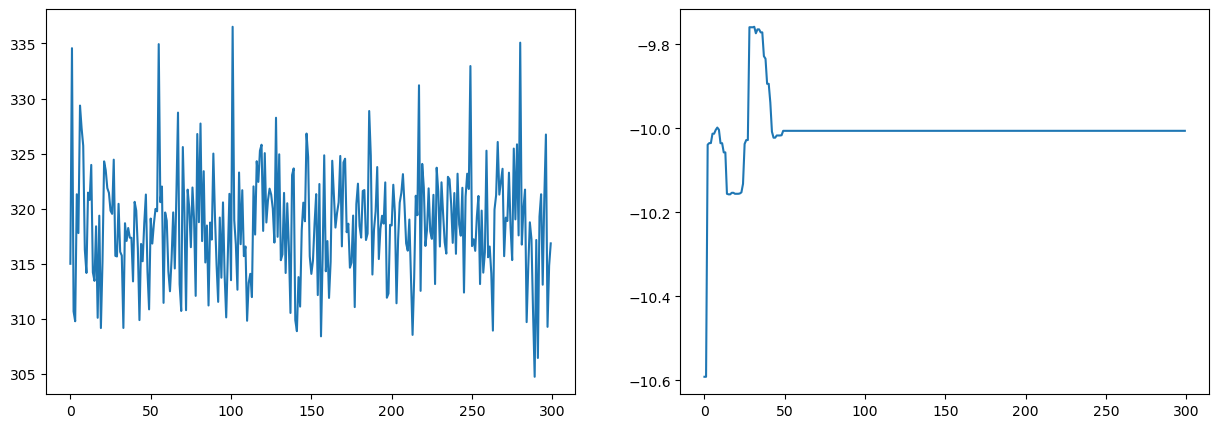

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].plot(objhist)
axes[1].plot(priorhist)

true_tunings = model.observation.mapping([true_weights, None], x_grid).Y.T
est_tunings = model.observation.mapping(est_params, x_grid).Y.T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5), subplot_kw={'projection': None})

for i in range(3):       
    ax1.plot(est_tunings[i], c='green', alpha=.5)
    ax1.plot(true_tunings[i], c='k', alpha=.5)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(est_tunings[0], est_tunings[1], est_tunings[2], c='green', alpha=.5)
ax2.plot(true_tunings[0], true_tunings[1], true_tunings[2], c='k', alpha=.5)
plt.tight_layout()
plt.show()